# Goal 2：真实四模式、搜索预算与冻结记忆

本工作 Notebook 对应 LLM 作业的四模式和示范记忆对照。生产 A/B/C 调度与被评估系统的模型调用单独计数。默认复算使用已经锁定的真实提议，身份是 RECOMPUTE，不伪装为新 LIVE。

In [1]:
from pathlib import Path
import sys, json, tempfile, shutil
from html import escape
from IPython.display import display, Image, HTML
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').is_file() and (p/'task1').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from task1.workflow.io import read_json, digest, object_hash
from task1.workflow.g2_provider import ExperimentProvider
model_sentinel = {'calls': 0}
def reject_model_call(*args, **kwargs):
    model_sentinel['calls'] += 1
    raise RuntimeError('RECOMPUTE_FORBIDS_NEW_MODEL_CALLS')
ExperimentProvider.call = reject_model_call
EV = ROOT/'task1/evidence/goal2'
current = read_json(EV/'current_runs.json')
contract = read_json(ROOT/'task1/config/goal2/contract.json')
split = read_json(EV/'data/split_manifest.json')
MODE = 'RECOMPUTE'
ENABLE_LIVE = False
assert MODE == 'RECOMPUTE' and ENABLE_LIVE is False, '新的 LIVE 调用须使用独立命令并显式启用，默认 Notebook 不发起模型请求。'
WORK = Path(tempfile.mkdtemp(prefix='sc-g2-notebook-'))
def show(rows):
    rows = list(rows)
    columns = list(dict.fromkeys(key for row in rows for key in row))
    header = ''.join('<th>'+escape(str(key))+'</th>' for key in columns)
    body = ''.join('<tr>'+''.join('<td>'+escape(str(row.get(key, '')))+'</td>' for key in columns)+'</tr>' for row in rows)
    display(HTML('<table><thead><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))
def figure(name):
    directory = Path(recomputed.get('figure_directory', WORK/'figures'))
    target = directory/(name+'.png')
    assert target.is_file(), f'复算图缺失: {target}'
    display(Image(filename=str(target), width=1050))
print('运行方式:', MODE, '| 新模型调用:', 0)
print('原始来源 datum:', contract['source_crs'], '| 单位: 工作米 / 原始相对秒')
print('当前固定分区:', {name:len(ids) for name,ids in split['splits'].items()})


运行方式: RECOMPUTE | 新模型调用: 0
原始来源 datum: UNVERIFIED | 单位: 工作米 / 原始相对秒
当前固定分区: {'PILOT_REGRESSION': 7, 'DEMO_MEMORY': 60, 'DEVELOPMENT': 120, 'G2_EVAL': 120, 'G3_RESERVED': 11079}


## 四种决策路径

| 模式 | 决策模型 | 搜索反馈 | 示范记忆 |
|---|---|---|---|
| llm-only | 一次真实锁定提议 | 无 | 无 |
| search-only | 严格 0 次；不实例化 Provider | 确定性至多 20 候选 | 无 |
| llm+search | 至多 3 回合真实决策 | 仅本 episode 已执行结果 | 无 |
| llm+memory+search | 相同模型、回合、预算 | 同上 | 冻结 DEMO_MEMORY，只读 |

一次调用至多 8 张诊断卡，调用数按实际批次算。LLM-only 的计算预算不同是结构消融的一部分，不伪称等量计算。

## 从 raw 与已保存真实提议重建确定性执行

复算重新处理开发和三次阶段评测中每个实际候选，检查原始提议合法性、预算、选择与锁定后评价；不用固定 Mock 答案。Provider 哨兵阻断任何意外模型调用，持久记忆保持原哈希。

In [2]:
from task1.scripts.goal2 import recompute
recomputed = recompute(topic='modes', output_directory=WORK, rebuild_figures=True)
assert recomputed['status'] == 'VERIFIED', recomputed
assert recomputed['new_model_calls'] == 0, recomputed
assert model_sentinel['calls'] == 0, model_sentinel
print('从 raw 和冻结提议复算:', recomputed['status'])
print('新增模型调用:', recomputed['new_model_calls'])
print('检查项数量:', len(recomputed['checks']))
show(recomputed['checks'][:20])
print('全部检查结果保存在独立复算输出，不把重复计算计为新独立实验。')


{"figures": 11, "raster_check": "PASSED", "visual_inspection": "PENDING_ACTUAL_IMAGE_REVIEW"}
从 raw 和冻结提议复算: VERIFIED
新增模型调用: 0
检查项数量: 3


全部检查结果保存在独立复算输出，不把重复计算计为新独立实验。


In [3]:
mode_run = EV/'runs'/current['mode_evaluation']
mode_manifest = read_json(mode_run/'manifest.json')
episodes = []
for entry in mode_manifest['mode_episodes']:
    path = mode_run/entry['path']
    assert digest(path) == entry['sha256']
    episodes.append(read_json(path))
mode_rows = [row for episode in episodes for row in episode['records']]
show([{'mode':episode['mode'],'episode':episode['episode'],'records':len(episode['input_ids']),'classification':episode['classification'],'model_dispatches':episode['resources']['experiment_model_dispatches'],'candidate_evaluations':episode['resources']['candidate_evaluations'],'elapsed_seconds':episode['elapsed_seconds']} for episode in episodes])
assert all(episode['resources']['experiment_model_dispatches']==0 for episode in episodes if episode['mode']=='search-only')

mode,episode,records,classification,model_dispatches,candidate_evaluations,elapsed_seconds
llm-only,1,8,LIVE_EXPERIMENT,1,8,33.46869322600105
llm-only,1,8,LIVE_EXPERIMENT,1,16,38.251071872000466
llm-only,1,8,LIVE_EXPERIMENT,1,9,37.54238970499864
llm-only,2,8,LIVE_EXPERIMENT,1,12,36.548248688002786
llm-only,2,8,LIVE_EXPERIMENT,1,12,35.06862661099876
llm-only,2,8,LIVE_EXPERIMENT,1,16,36.5245116340011
llm-only,3,8,LIVE_EXPERIMENT,1,16,38.14000402900274
llm-only,3,8,LIVE_EXPERIMENT,1,12,40.008700097001565
llm-only,3,8,LIVE_EXPERIMENT,1,8,28.88150631100143
search-only,1,8,DETERMINISTIC_ZERO_MODEL_SEARCH,0,160,10.919305096002063


## 逐记录配对、失效动作与成本

同一原始记录的三 episode 保留为重复决策，不能当作三个独立样本。图中描述相对该记录 reference 的有符号变化；空误差不填 0。原始非法提议和工程回退分别显示，回退不能替原始建议取得合法性分数。

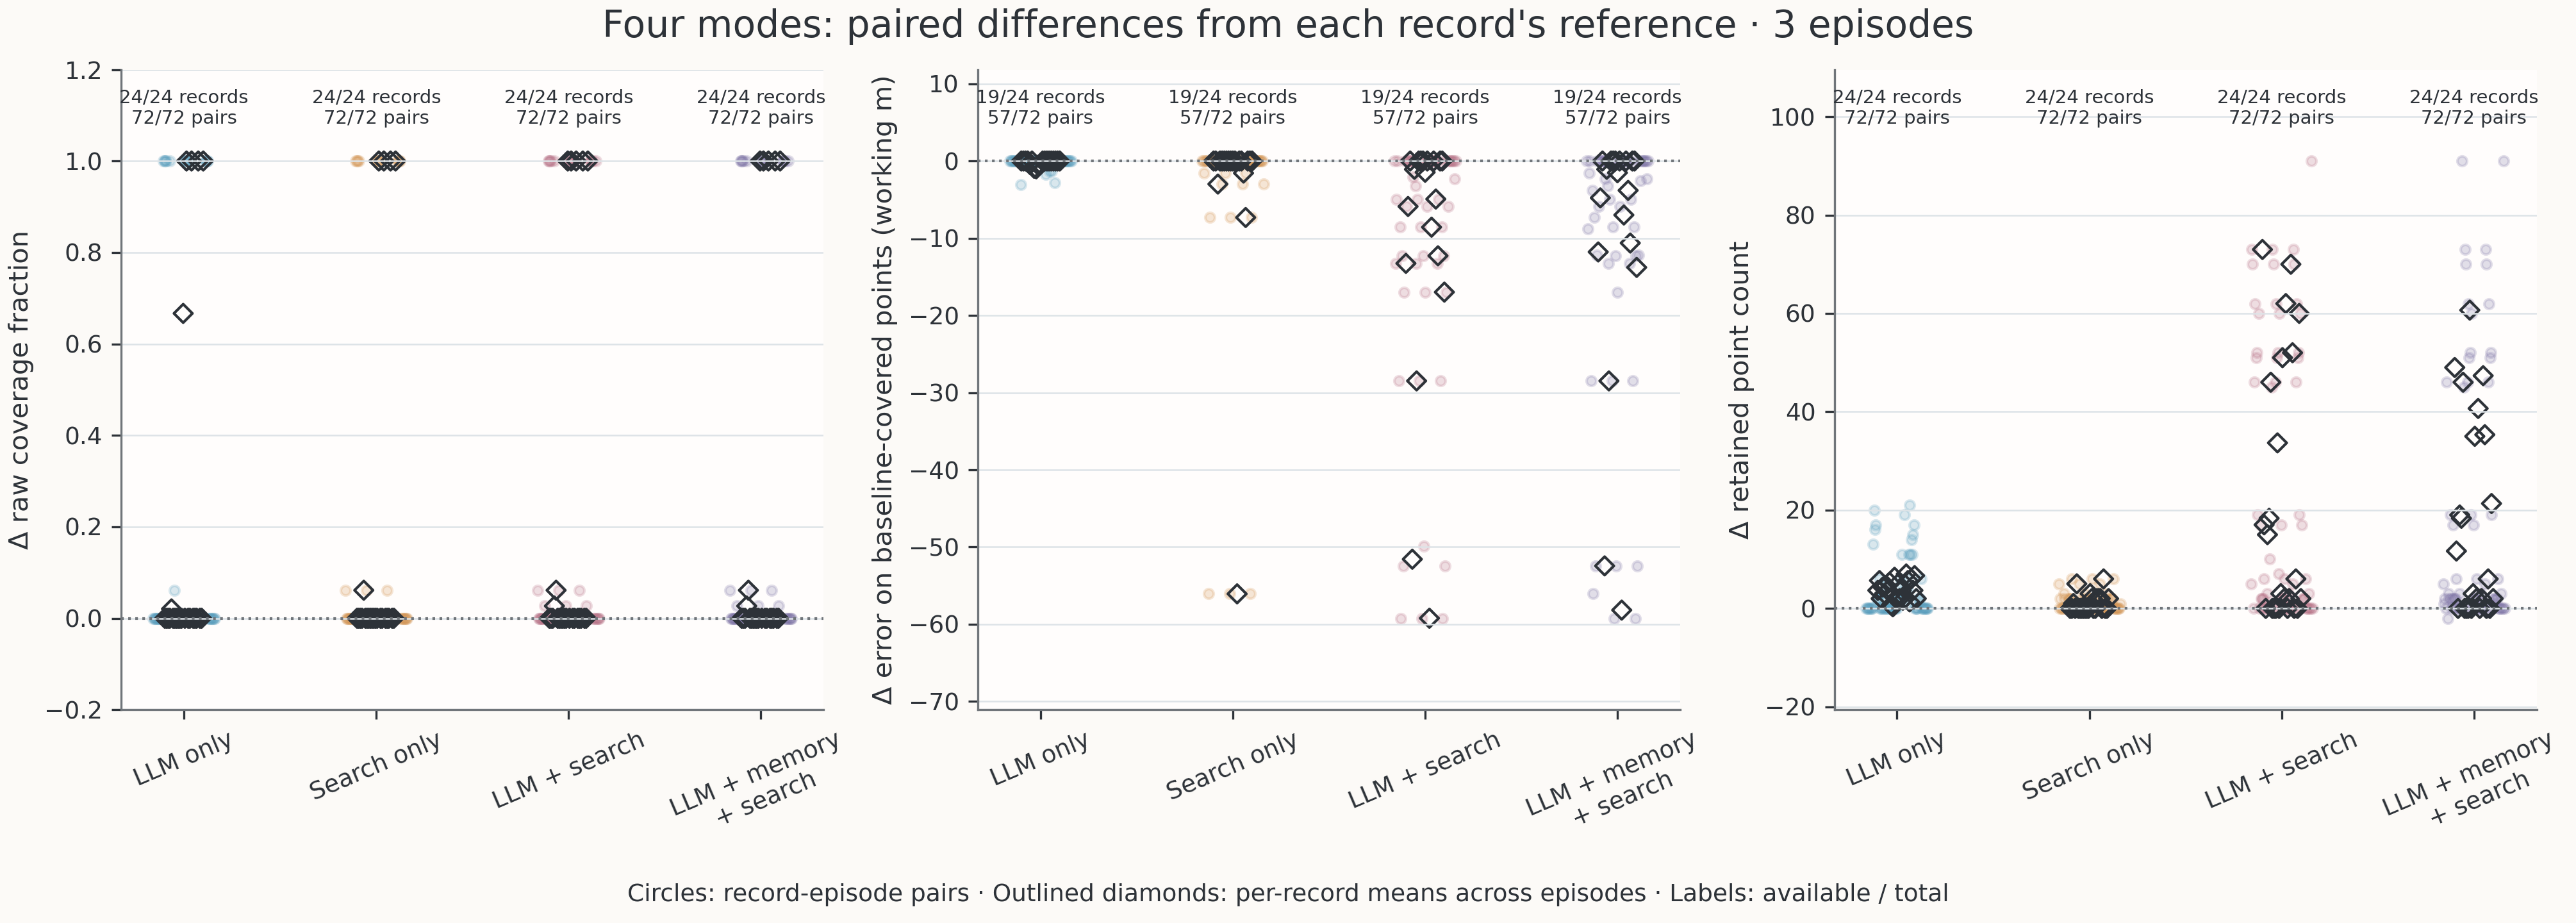

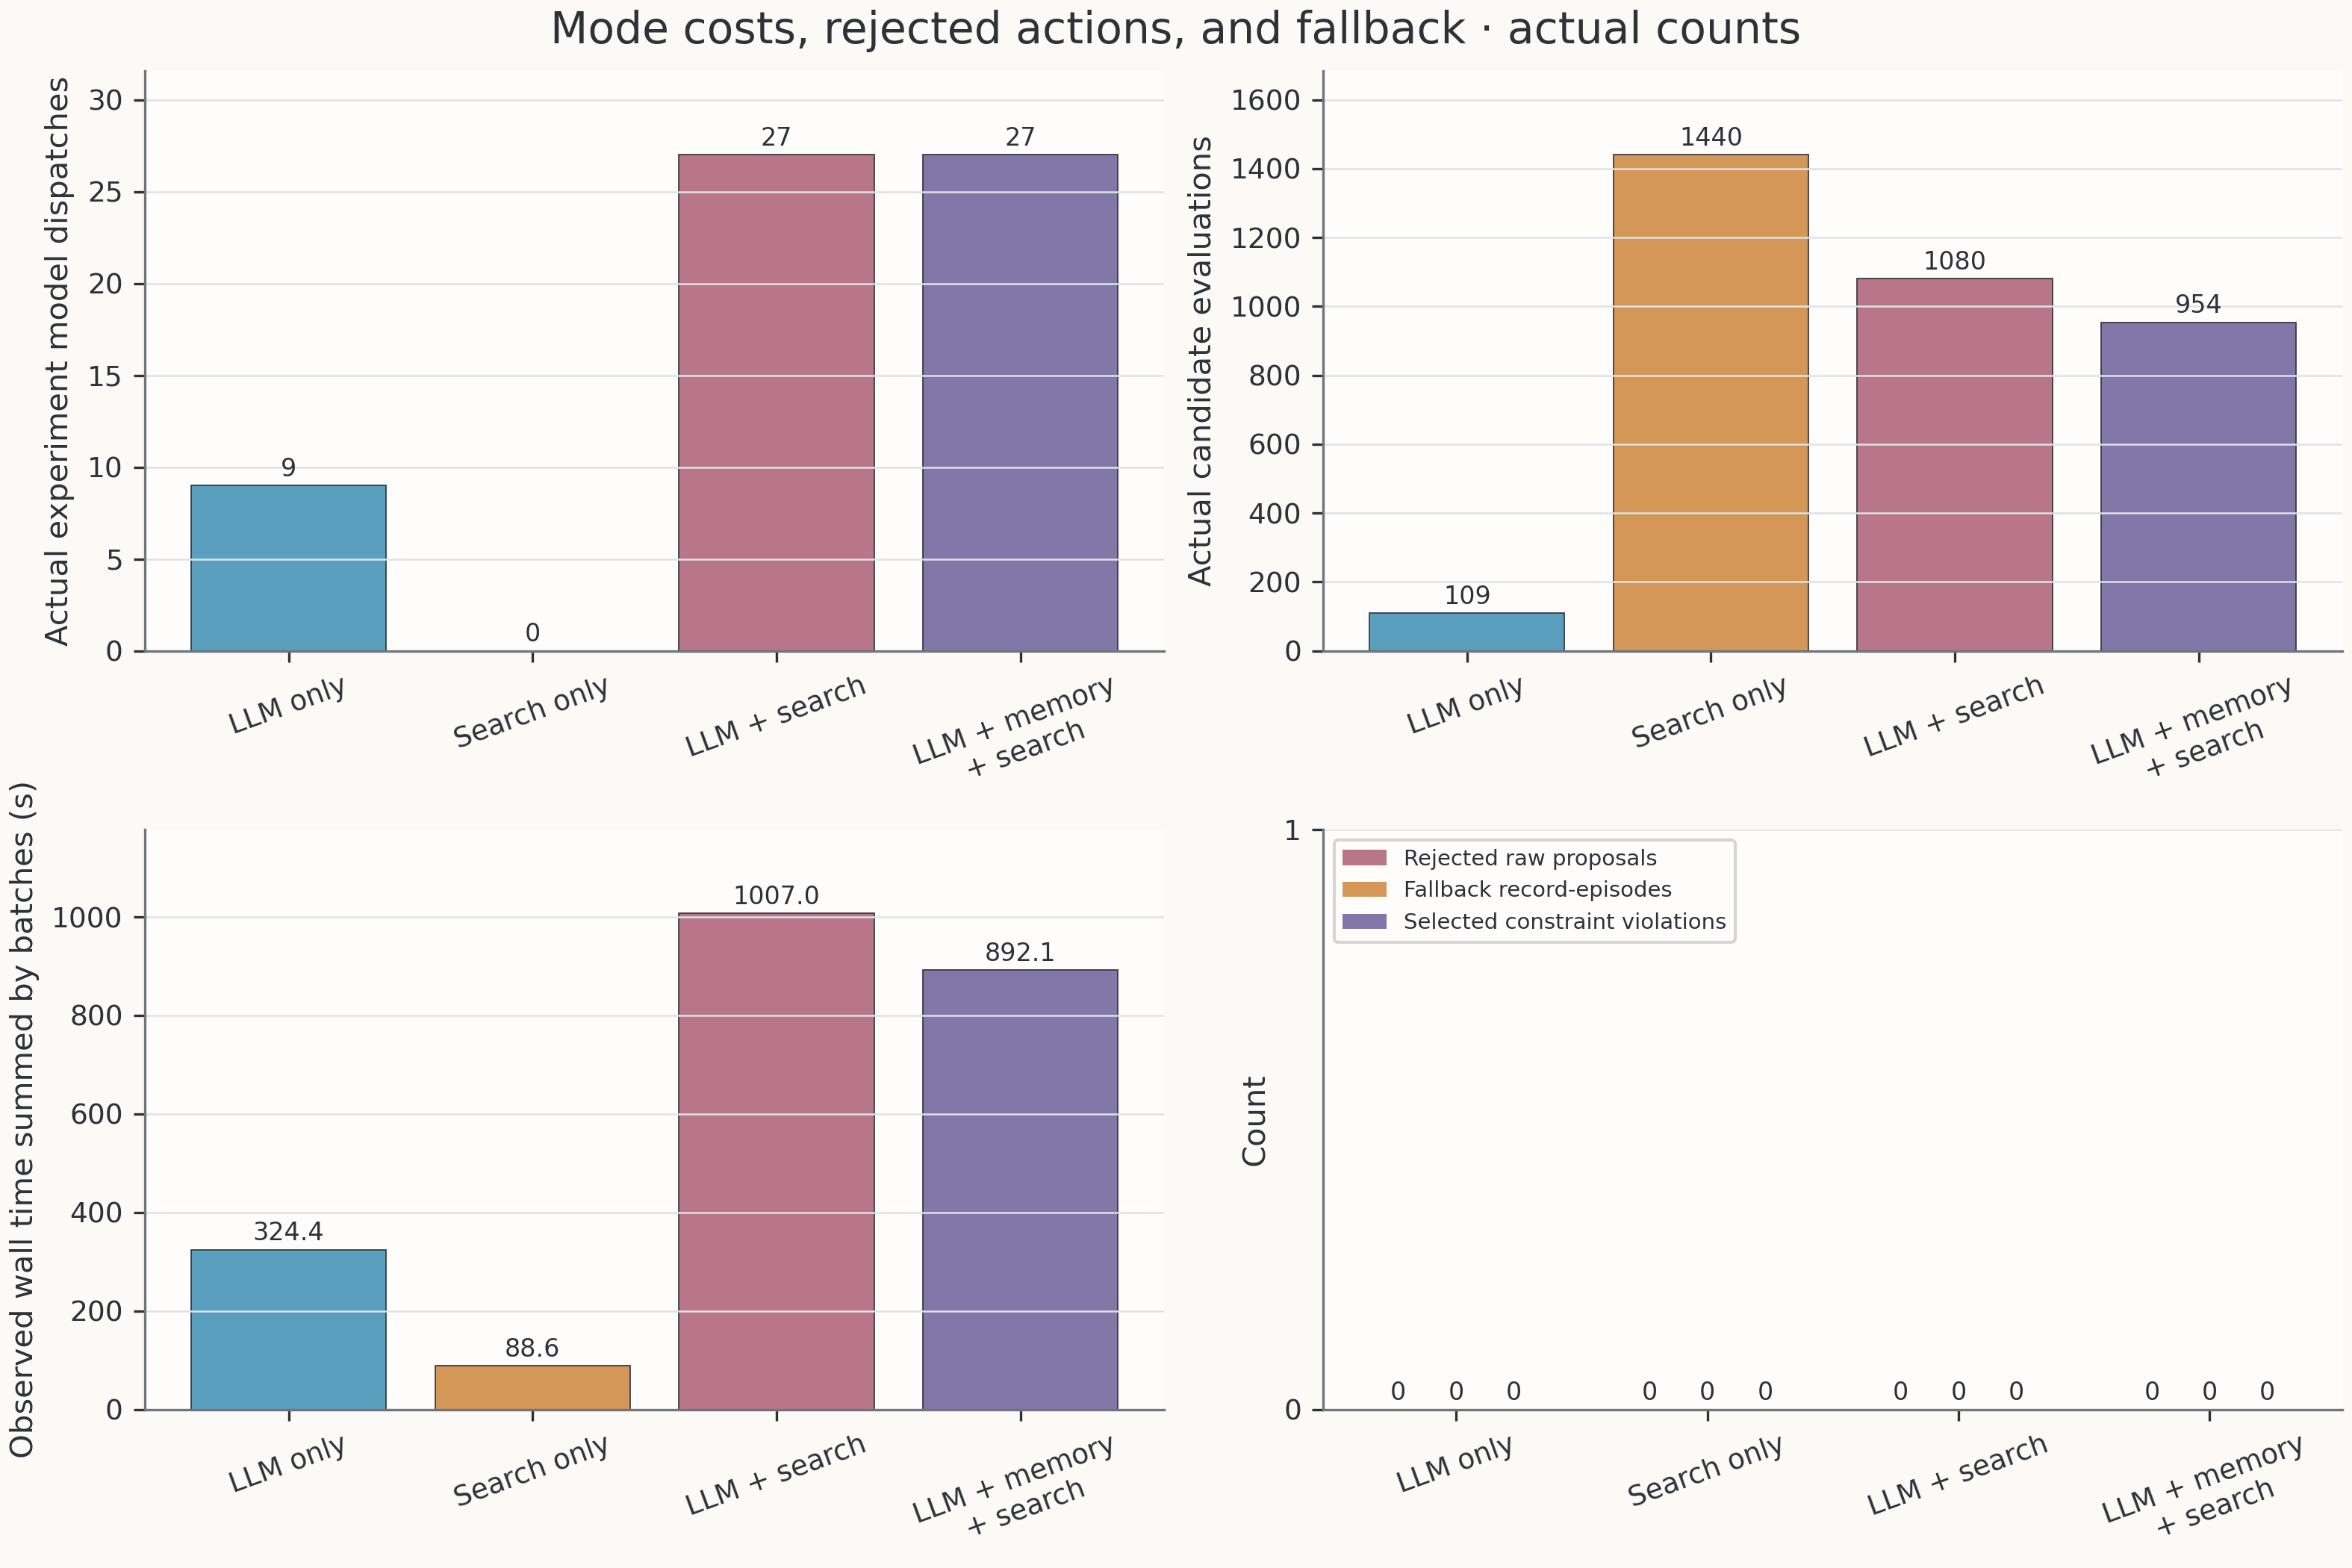

record_id,mode,episode,round,legal,executed,rejection_reason,original
1887,llm-only,1,1,True,True,None,"{'candidate_id': '1887-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: 18 distance breaks make segmentation changes consequential, and aggregate observations do not establish a protected improvement.'}"
10003,llm-only,1,1,True,True,None,"{'candidate_id': '10003-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: no raw breaks are reported, and aggregate observations cannot justify changing direction filtering or the existing 5-metre DP tolerance.'}"
8424,llm-only,1,1,True,True,None,"{'candidate_id': '8424-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: path and span summaries do not establish a candidate that improves protected coverage or fidelity.'}"
2225,llm-only,1,1,True,True,None,"{'candidate_id': '2225-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: duplicate edges and unavailable directions do not justify additional deletion; undefined direction windows remain protected by the specified algorithm.'}"
2064,llm-only,1,1,True,True,None,"{'candidate_id': '2064-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: four distance breaks are reported, but segment sizes and geometry needed to assess filter changes are unavailable.'}"
7253,llm-only,1,1,True,True,None,"{'candidate_id': '7253-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: 14 duplicate edges alone provide no evidence that parameter changes would improve protected metrics.'}"
588,llm-only,1,1,True,True,None,"{'candidate_id': '588-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: preserve the reported common raw breakpoint; no geometry or feedback supports a beneficial alternative.'}"
8522,llm-only,1,1,True,True,None,"{'candidate_id': '8522-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}, 'metric_id': 'n_final', 'predicted_sign': 'unchanged', 'reason': 'Retain reference: four raw breaks and two zero-time edges do not establish a protected improvement from any threshold change.'}"
1880,llm-only,1,1,True,True,None,"{'candidate_id': '1880-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 2}, 'metric_id': 'common_max_error', 'predicted_sign': 'not_predicted', 'reason': 'Lower DP tolerance while preserving S/D and raw breakpoint handling; aggregate observations cannot establish a strict common-error change.'}"
9673,llm-only,1,1,True,True,None,"{'candidate_id': '9673-c1', 'parameters': {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 2}, 'metric_id': 'common_max_error', 'predicted_sign': 'not_predicted', 'reason': 'Test lower DP tolerance with unchanged segmentation and direction filtering; duplicate counts do not determine common geometric error.'}"


全部原始提议条目: 467 ；这里只展示前12条，完整来源保留。


In [4]:
figure('four_mode_paired_results')
figure('four_mode_failures_and_cost')
proposal_rows=[]
for row in mode_rows:
    for proposal in row['proposal_records']:
        proposal_rows.append({'record_id':row['record_id'],'mode':row['mode'],'episode':row['episode'],'round':proposal['round'],'legal':proposal['legal'],'executed':proposal['executed'],'rejection_reason':proposal.get('rejection_reason',proposal.get('reason')),'original':proposal.get('original')})
show(proposal_rows[:12])
print('全部原始提议条目:',len(proposal_rows),'；这里只展示前12条，完整来源保留。')

## 检索、消费与泄漏隔离

DEMO 60 条先经过确定性核验，再冻结快照。检索按父记录/同源组、分区、版本和原始诊断适用性过滤；评测不写记忆、不读取其他模式结果。检索命中、模型引用、参数与案例一致是不同级别的可观察事实，并不单独证明因果收益。

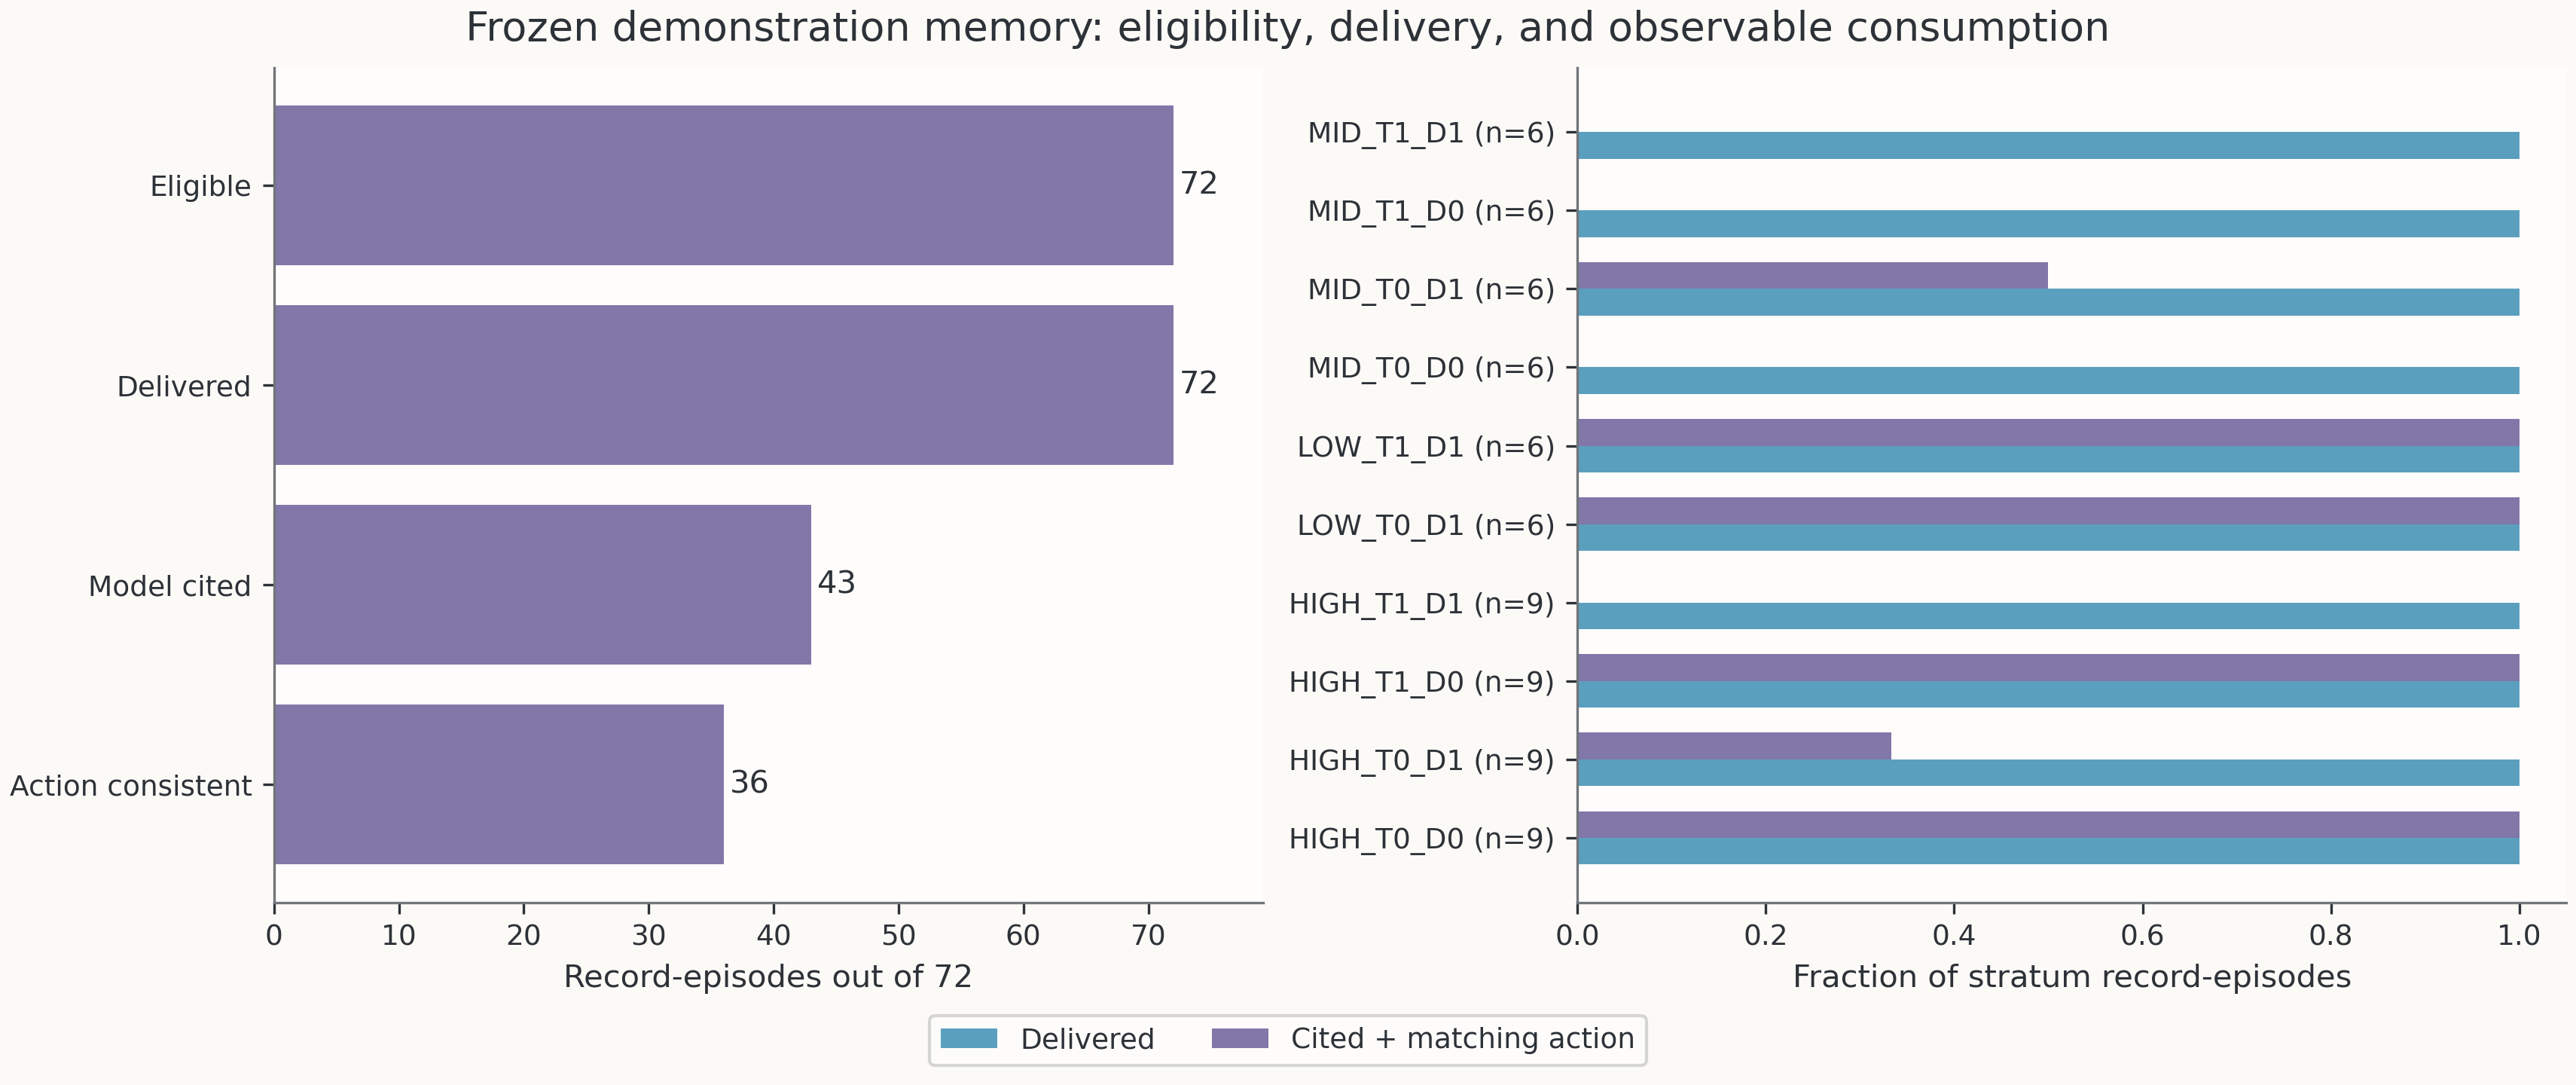

全部正式记忆episode使用同一snapshot: 2330543c3a443532891936ac29d4080cb6e5f45c58e2976cc81c8fa67c6607d6


record_id,episode,round,retrieved_eligible,delivered_ids,model_cited_valid,model_cited_invalid,action_consistent,causal_benefit_proven
1887,1,1,7,"['DEMO-9636', 'DEMO-2125', 'DEMO-2065']",['DEMO-9636'],[],"[{'memory_id': 'DEMO-9636', 'candidate_id': '1887-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}]",False
1887,1,2,7,"['DEMO-9636', 'DEMO-2125', 'DEMO-2065']",[],[],[],False
10003,1,1,7,"['DEMO-11076', 'DEMO-9600', 'DEMO-3456']","['DEMO-11076', 'DEMO-9600']",[],"[{'memory_id': 'DEMO-11076', 'candidate_id': '10003-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}, {'memory_id': 'DEMO-9600', 'candidate_id': '10003-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}]",False
10003,1,2,7,"['DEMO-11076', 'DEMO-9600', 'DEMO-3456']",[],[],[],False
8424,1,1,7,"['DEMO-11076', 'DEMO-9600', 'DEMO-3456']","['DEMO-11076', 'DEMO-9600']",[],"[{'memory_id': 'DEMO-11076', 'candidate_id': '8424-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}, {'memory_id': 'DEMO-9600', 'candidate_id': '8424-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}]",False
8424,1,2,7,"['DEMO-11076', 'DEMO-9600', 'DEMO-3456']",[],[],[],False
2225,1,1,7,"['DEMO-8718', 'DEMO-10471', 'DEMO-2254']",['DEMO-2254'],[],"[{'memory_id': 'DEMO-2254', 'candidate_id': '2225-r1', 'kind': 'CITED_AND_PARAMETERS_MATCH_VERIFIED_OUTCOME'}]",False
2225,1,2,7,"['DEMO-8718', 'DEMO-10471', 'DEMO-2254']",[],[],[],False
2064,1,1,7,"['DEMO-9820', 'DEMO-10471', 'DEMO-661']",[],[],[],False
2064,1,2,7,"['DEMO-9820', 'DEMO-10471', 'DEMO-661']",[],[],[],False


In [5]:
figure('memory_coverage_and_consumption')
memory_rows = [row for row in mode_rows if row['mode']=='llm+memory+search']
hashes = sorted({row['memory_snapshot_hash'] for row in memory_rows})
assert len(hashes)==1 and hashes[0], hashes
print('全部正式记忆episode使用同一snapshot:',hashes[0])
show([{'record_id':row['record_id'],'episode':row['episode'],'round':rd['round'],**rd['memory_consumption']} for row in memory_rows for rd in row['rounds'] if 'memory_consumption' in rd][:12])

## 真实调用与理解边界

原始请求、响应、provider/session ID 和可见 tokens 在各 round 的调用目录；底层不可见请求/费用保持 unknown。实际预测只和事前绑定的 metric/reference/sign 比较。新的 LIVE 调用使用 `python -m task1.scripts.goal2 --help` 中明确的 LIVE 入口；改变本 Notebook 的显示字符串不会启动模型。

In [6]:
print('本 Notebook 新模型调用:',recomputed['new_model_calls'])
print('先前真实正式派发:',sum(episode['resources']['experiment_model_dispatches'] for episode in episodes))
print('GPT_SECOND_REVIEW=PENDING; Submission=NOT_READY')
shutil.rmtree(WORK)

本 Notebook 新模型调用: 0
先前真实正式派发: 63
GPT_SECOND_REVIEW=PENDING; Submission=NOT_READY
